<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #fff5ef; color: #003152;">

**Project:** When Weight Doesn’t Weigh the same on Everyone: Applying The Lancet’s Clinical Obesity Framework to Map Phenotypic Diagnostic Gaps in NHANES 2021–2023  
**Source:** National Health and Nutrition Examination Survey (NHANES), Aug 2021–Aug 2023 Cycle  
**Key analysis:** Survey-weighted GEE Poisson regressions to estimate population-adjusted Relative Risks (RR) across composite clinical risk indices (e.g., FIB-4) and end-organ damage markers.  
**Version:** 1.0  

---

**Technical Focus:** Statistical inference and epidemiological modeling on a pre-curated, structurally sound adult cohort ($N=1,588$).  
**Key Goal:** Compare standard BMI thresholds against The Lancet Clinical Obesity criteria and our proposed phenotypic stratification (peripheral vs. classic) in predicting systemic risk indices and sub-clinical end-organ damage.

</div>

In [43]:
from IPython.display import display, Markdown, HTML
import re
import math
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.weightstats import DescrStatsW
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objects as go
from pathlib import Path

## 🎯 Analytical Objectives
---

We will operationalize *The Lancet Diabetes & Endocrinology* framework to evaluate the diverse spectrum of obesity beyond singular anthropometric markers like BMI.

1. **Multivariable Baseline Profiling:** Summarizing survey-weighted continuous and categorical demographic, physical examination, and laboratory biomarkers across unstratified overall and phenotypic cohorts (`Control`, `Peripheral`, `Classic`) using Weighted Least Squares (WLS) and Masked Variance Units (MVU) cluster variance estimation.

2. **Indices Stratification:** Evaluating composite metabolic, hepatic, and cardiovascular risk indices (e.g., METS-IR, TyG, API, FLI, FIB-4, FNI, PREVENT) and testing phenotypic separation via survey-adjusted Wald $F$-tests.

3. **Behavioral & Demographic Covariate Integration:** Adjusting for key socio-demographic and patient-reported clinical confounders (e.g., age, sex, history of chronic disease) to isolate independent phenotypic and biochemical contributions to systemic risk.

4. **End-Organ Damage Mapping:** Mapping the population-adjusted prevalence and multi-tier flow (via survey-weighted Sankey diagrams) across renal, hepatic, metabolic, and multi-organ composite damage flags.

5. **Survey-Weighted GEE Poisson Regression Modeling:** Executing a sequential three-step regression framework using Generalized Estimating Equations (GEE) with a Poisson family and log link function to estimate population-adjusted Relative Risks ($\text{RR}$) and $95\%$ Confidence Intervals ($\text{CI}$). Sequential models ($\text{M1}$: Structural Phenotypes, $\text{M2}$: Cross-Spillover Indices, $\text{M3}$: Integrated Phenotype-Index Models) are evaluated for parsimony and model fit using the Quasi-Likelihood under Independence Model Criterion ($\text{QIC}$) across a sample-aligned cohort ($N = 1,588$).

In [44]:
class Loader:
    """
    Encapsulates file ingestion and cohort verification for the NHANES dataset.
    Ensures that the structured parquet files are loaded without data degradation.
    
    Args:
        data_dir (str): Relative or absolute path to the processed data outputs.
    """

    def __init__(self, data_dir: str = "../outputs"):
        self.data_dir = Path(data_dir)

    def base(self, filename: str = "nhanes_processed_cohort.parquet") -> pd.DataFrame:
        """
        Loads the baseline processed registry and validates data integrity.
        
        Args:
            filename (str): The name of the target parquet file.
        """
        path = self.data_dir / filename
        print(f"[DataLoader] Ingesting registry from: {path}")
        
        df = pd.read_parquet(path)
        
        # Immediate analytical check to guarantee no data degradation
        print(f"[DataLoader] Verification Successful. N = {df.shape[0]} rows.")
        return df

In [45]:
class Processor:
    """
    Handles descriptive statistics of continuous and binary variables.
    Utilizes Weighted Least Squares (WLS) and clustering to account for complex survey design weights

    Args:
        dataframe (pd.DataFrame): The clinical cohort data.
        metadata (dict, optional): Associated dataset metadata. Defaults to None.
    """

    def __init__(self, dataframe, metadata=None):
        self.df = dataframe.copy()

        # Boolean mask isolating the designated clinical cohort
        self.mask = self.df["cohort"] == 1
        self.has_cohort = self.mask.any()

        # Complex survey design variables required for accurate variance estimation
        self.design_cols = ["groups", "WTSAF2YR"]
        
        # Coerce survey variables to numeric types for WLS compatibility
        self.df[self.design_cols] = self.df[self.design_cols].apply(pd.to_numeric, errors='coerce')

    def index_cutoff(self, variable: str = None, cutoff: str = None, label: str = None):
        """
        Applies mathematical thresholds to a continuous index to generate binary classifications.
        Supports string expressions (e.g., '>= 30'), numeric values, or multi-level lists.
        
        Args:
            variable (str): The continuous column name to evaluate.
            cutoff (str/float): The logical threshold to apply.
            label (str): The name of the new boolean/binary column to generate.
        """
        if not self.has_cohort:
            return self.df

        # Force data alignment to numeric to avoid string comparison errors during evaluation
        self.df[variable] = pd.to_numeric(self.df[variable], errors='coerce')
        df_cohort = self.df[self.mask]

        # Operator mapping for safe vector evaluation without using standard eval()
        op_map = {
            ">=": lambda s, v: s >= v,
            ">":  lambda s, v: s > v,
            "<=": lambda s, v: s <= v,
            "<":  lambda s, v: s < v,
            "==": lambda s, v: s == v,
            "!=": lambda s, v: s != v
        }
 
        if isinstance(cutoff, str):
            # Match operator and numeric value
            match = re.match(r"^\s*(>=|>|<=|<|==|!=)\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$", cutoff)
            
            if not match:
                raise ValueError(f"Invalid cutoff string format: '{cutoff}'. Expected format like '>= 30' or '< 4.65'")
                
            op_str, val_str = match.groups()
            op_func = op_map[op_str]
            threshold_val = float(val_str)

            # Apply boolean mask across the vector
            boolean_vector = op_func(df_cohort[variable], threshold_val)
            
            # Map the boolean outcome back to the main dataframe as a float indicator (1.0/0.0)
            self.df.loc[self.mask, label] = boolean_vector.astype(float)

        else:
            raise ValueError("Cutoff must be a string (e.g., '>= 30')")

        return self.df

    def index_indeterminates(self, variable: str, rule_out: str, rule_in: str, label: str):
        """
        Identifies intermediate risk tiers for scores with dual cutoffs (e.g., FIB-4, FLI, FNI).
        Preserves missing data (NaN) integrity across the cohort mask.
        
        Args:
            variable (str): Continuous raw variable column name (e.g., 'fib4')
            rule_out (str): Threshold expression for low risk (e.g., '< 1.45')
            rule_in (str): Threshold expression for high risk (e.g., '> 3.25')
            label (str):Target column name for the output flag (e.g., 'fib4_indeterminate')
        """
        if not self.has_cohort:
            return self.df

        # Generate the binary rule-out and rule-in columns dynamically
        out_col = f"{variable}_rule_out"
        in_col  = f"{variable}_rule_in"
        
        self.index_cutoff(variable=variable, cutoff=rule_out, label=out_col)
        self.index_cutoff(variable=variable, cutoff=rule_in, label=in_col)

        # Isolate valid non-missing observations within the active cohort mask
        valid_mask = self.mask & self.df[variable].notna()

        # An observation is indeterminate if it is NEITHER ruled out NOR ruled in
        is_indeterminate = (self.df[out_col] == 0) & (self.df[in_col] == 0)

        # Write back clean 1.0 / 0.0 values, preserving NaNs for missing raw values
        self.df.loc[valid_mask, label] = is_indeterminate.astype(float)
        self.df.loc[self.mask & self.df[variable].isna(), label] = np.nan

        return self.df
    
    def table(self, target_vars=None, label_map=None):
        """
        Generates a stratified table summarizing mean, interquartile ranges, 
        standard errors, and valid counts per variable, partitioned by obesity phenotype
        plus the overall unstratified population.
        
        Args:
            target_vars (list): List of column names to summarize.
            rename_dict (dict, optional): Mapping of raw variable names to clinical labels.
        """
        if not target_vars:
            return

        # Coerce target variables to numeric for running WLS    
        self.df[target_vars] = self.df[target_vars].apply(pd.to_numeric, errors='coerce')

        # Global Clean: Filter to cohort and drop records missing survey design info
        cohort_df = self.df[self.df["cohort"] == True].dropna(subset=self.design_cols).copy()
        print(f"Fasting Cohort Size: {len(cohort_df)}")

        # Identify unclassified rows
        unclassified_mask = (
            (cohort_df['phenotype_control'] != True) & 
            (cohort_df['phenotype_peripheral'] != True) & 
            (cohort_df['phenotype_classic'] != True)
        )

        classified = cohort_df[~unclassified_mask]
        unclassified = cohort_df[unclassified_mask]

        print(f"Total Outliers from cohort: {len(unclassified)}")
        print(f"Final Analysis Cohort Size: {len(classified)}")

        phenotype_map = {
            "overall": None,
            "control": "phenotype_control",
            "peripheral": "phenotype_peripheral",
            "classic": "phenotype_classic"
        }

        results = []
        display_order = []

        # Outer Loop: Iterate through each phenotype mapping
        for pheno_name, col_name in phenotype_map.items():
            pheno_df = cohort_df if col_name is None else cohort_df[cohort_df[col_name] == True]
            
            # Inner Loop: Analyze each target variable using pairwise deletion
            for var in target_vars:
                local_df = pheno_df.dropna(subset=[var]).copy()
                
                if len(local_df) == 0:
                    continue
                    
                # Check if variable is a binary 0/1 flag
                unique_vals = set(local_df[var].unique()) - {np.nan}
                is_binary = unique_vals.issubset({0, 1, 0.0, 1.0})
                
                exog = pd.DataFrame({'const': 1.0}, index=local_df.index)
                
                # Fit WLS model
                model = sm.WLS(local_df[var], exog, weights=local_df["WTSAF2YR"])
                res = model.fit(cov_type='cluster', cov_kwds={'groups': local_df["groups"]})
                
                # Extract base statistics
                mean_val = res.params.iloc[0]
                se_val = res.bse.iloc[0]
                lci_val = res.conf_int().iloc[0, 0]
                uci_val = res.conf_int().iloc[0, 1]
                
                if not is_binary:
                    weighted_stats = DescrStatsW(local_df[var], weights=local_df["WTSAF2YR"])
                    quantiles = weighted_stats.quantile([0.25, 0.75])
                    p25_val = quantiles.loc[0.25]
                    p75_val = quantiles.loc[0.75]
                else:
                    p25_val = np.nan
                    p75_val = np.nan

                # Label Mapping Pattern
                display_var = var
                if label_map and var in label_map:
                    display_var = label_map[var]

                # Adjust percentages and units for binary flags
                if is_binary:
                    mean_val *= 100
                    se_val *= 100
                    lci_val *= 100
                    uci_val *= 100
                    if not display_var.endswith("(%)"):
                        display_var = f"{display_var} (%)"

                if display_var not in display_order:
                    display_order.append(display_var)
                
                results.append({
                    "Phenotype": pheno_name,
                    "Variable": display_var,
                    "N_Valid": len(local_df),
                    "Mean": mean_val,
                    "P25": p25_val,
                    "P75": p75_val,
                    "SE": se_val,
                    "LCI": lci_val,
                    "UCI": uci_val
                })

        # Compile and pivot
        table_stratified = pd.DataFrame(results)
        table_stratified[["P25", "P75"]] = table_stratified[["P25", "P75"]].fillna("-")

        pivot_table = table_stratified.pivot(
            index="Variable", 
            columns="Phenotype", 
            values=["Mean", "P25", "P75", "SE", "N_Valid"]
        )

        # Reindex to preserve target_vars order and phenotype progression
        pivot_table = pivot_table.reindex(index=display_order)
        pivot_table = pivot_table.reindex(
            columns=['overall', 'control', 'peripheral', 'classic'], 
            level='Phenotype'
        )

        return display(pivot_table)

In [46]:
class Regression:
    """
    Executes a 3-step regression strategy to evaluate the impact of Obesity Phenotypes, 
    Cross-Spillover Indices, and Integrated Models on end-organ damage. 
    Utilizes Generalized Estimating Equations (GEE) to accommodate survey weights and clustering.

    Args:
        dataframe (pd.DataFrame): The analytical clinical dataset.
    """

    def __init__(self, dataframe: pd.DataFrame):
        self.df = dataframe.copy()
        self.design_cols = ["groups", "WTSAF2YR"]
        
        # Ensure predictors and survey weights exist, dropping records with missing design data
        self.df.dropna(subset=self.design_cols, inplace=True)
        self.df[self.design_cols] = self.df[self.design_cols].apply(pd.to_numeric, errors='coerce')
        
        # Convert boolean phenotype designations to standard 0/1 integers for GLM compatibility
        pheno_cols = ["phenotype_control", "phenotype_peripheral", "phenotype_classic"]
        for col in pheno_cols:
            if col in self.df.columns:
                self.df[col] = self.df[col].astype(int)

    def _fit_binomial_gee(self, formula: str, data: pd.DataFrame):
        """
        Internal method executing a survey-weighted Binomial Marginal GLM via GEE.
        Uses a Poisson family with a Log link to estimate relative risks.
        
        Args:
            formula (str): Patsy-style model formula.
            data (pd.DataFrame): The subsetted data containing no missing values.
        """
        model = sm.GEE.from_formula(
            formula=formula,
            family=sm.families.Poisson(link=sm.families.links.Log()),
            cov_struct=sm.cov_struct.Exchangeable(), 
            data=data,
            groups="groups", 
            weights=data["WTSAF2YR"]
        )
        return model.fit()
    
    def _prepare_clean_df(self, target_damage: str, variables: list):
        """
        Helper method generating an overlapping subset free of NaNs. 
        Ensures all sequential models utilize the exact same sample size (N) 
        for statistically valid QIC (Quasi-Likelihood under Independence Model Criterion) comparison.
        
        Args:
            target_damage (str): The dependent variable column name.
            variables (list): List of all independent variable column names.
        """
        cols_to_check = [target_damage] + variables + self.design_cols
        local_df = self.df.dropna(subset=cols_to_check).copy()
        local_df[target_damage] = local_df[target_damage].astype(int)
        return local_df

    def _print_tidy_summary(self, model_name: str, res, local_df):
        """
        Extracts and displays the coefficient tables and fundamental fit metrics.
        """
        qic, _ = res.qic(scale=1.0)
        
        print(f"=" * 98)
        print(f" MODEL: {model_name}")
        print(f"=" * 98)
        print(res.summary().tables[1]) 

        print(f"-" * 98)
        print(f" Fit Metrics:  QIC = {qic:.3f}  |  N = {len(local_df)}  |  Clusters = {local_df['groups'].nunique()}")
        print(f"=" * 98, f"\n")

        return res

    def model_1_phenotype(self, target_damage: str, all_indices: list, cofounders: list):
        """
        Execution of Model 1: Structural Phenotype -> Target Damage.
        Estimates the baseline risk associated strictly with obesity patterns.
        """
        cfd_str = " + ".join(cofounders)
        formula = f"{target_damage} ~ phenotype_peripheral + phenotype_classic + {cfd_str}"
        
        # Cleans the data using ALL indices to keep N consistent for later comparisons
        local_df = self._prepare_clean_df(target_damage, ["phenotype_peripheral", "phenotype_classic"] + all_indices + cofounders)
        res = self._fit_binomial_gee(formula, local_df)
        
        return self._print_tidy_summary("M1_Phenotype", res, local_df)
    
    def model_2_cross_spill(self, target_damage: str, current_index: str, all_indices: list, cofounders: list):
        """
        Execution of Model 2: Cross-Spillover Indices -> Alternate Organ Damage.
        Evaluates the predictive capacity of biochemical indices isolated from structural phenotypes.
        """
        cfd_str = " + ".join(cofounders)
        formula = f"{target_damage} ~ {current_index} + {cfd_str}"
        
        local_df = self._prepare_clean_df(target_damage, ["phenotype_peripheral", "phenotype_classic"] + all_indices + cofounders)
        res = self._fit_binomial_gee(formula, local_df)
        
        return self._print_tidy_summary(f"M2_CrossSpill ({current_index})", res, local_df)

    def model_3_integrated(self, target_damage: str, current_index: str, all_indices: list, cofounders: list):
        """
        Execution of Model 3: Phenotypes + Indices -> Target Damage.
        Assesses whether integrating structural profiles with biochemical indices yields superior QIC scores.
        """
        cfd_str = " + ".join(cofounders)
        formula = f"{target_damage} ~ phenotype_peripheral + phenotype_classic + {current_index} + {cfd_str}"
        
        local_df = self._prepare_clean_df(target_damage, ["phenotype_peripheral", "phenotype_classic"] + all_indices + cofounders)
        res = self._fit_binomial_gee(formula, local_df)
        
        return self._print_tidy_summary(f"M3_Integrated ({current_index})", res, local_df)

    def test_indices_phenotype_differences(
        self,
        biomarkers: list, 
        phenotype_col: str = "phenotype",
        weight_col: str = "WTSAF2YR",
        label_map: dict = None
    ):
        """
        Performs survey-weighted omnibus hypothesis testing (design-adjusted ANOVA equivalent)
        across obesity phenotypes using the existing categorical phenotype column.
        """
        results = []
        categories = ['Control', 'Peripheral', 'Classic']

        # Filter valid rows
        df_pheno = self.df.dropna(subset=[phenotype_col]).copy()

        # Normalize text formatting (Title Case) to ensure 1:1 match with categories
        df_pheno[phenotype_col] = df_pheno[phenotype_col].astype(str).str.strip().str.title()

        # Enforce CategoricalDtype safely without triggering Pandas4Warning
        cat_type = pd.CategoricalDtype(categories=categories, ordered=False)
        df_pheno[phenotype_col] = df_pheno[phenotype_col].astype(cat_type)

        # Drop any rows that didn't match the target categories
        df_pheno = df_pheno.dropna(subset=[phenotype_col])

        for biomarker in biomarkers:
            # Clean subset for active variable + weight
            subset = df_pheno.dropna(subset=[biomarker, weight_col]).copy()
            
            # Compute Survey-Weighted Means and SDs per phenotype
            group_stats = {}
            for pheno in categories:
                grp = subset[subset[phenotype_col] == pheno]
                
                w = grp[weight_col]
                x = grp[biomarker]
                
                # Safeguard against empty subsets or zero weight sums
                if grp.empty or w.sum() == 0:
                    group_stats[pheno] = "N/A"
                    continue

                w_mean = np.average(x, weights=w)
                w_var = np.average((x - w_mean)**2, weights=w)
                w_sd = np.sqrt(w_var)
                
                group_stats[pheno] = f"{w_mean:.2f} (±{w_sd:.2f})"

            # Design-Adjusted Hypothesis Test (Weighted Regression + Wald Test)
            try:
                model = smf.wls(
                    f"{biomarker} ~ C({phenotype_col}, Treatment(reference='Control'))", 
                    data=subset, 
                    weights=subset[weight_col]
                ).fit()
                
                # Joint Wald F-Test evaluating if ANY phenotype differs from Control
                wald_test = model.wald_test(
                    f"C({phenotype_col}, Treatment(reference='Control'))[T.Peripheral] = 0, "
                    f"C({phenotype_col}, Treatment(reference='Control'))[T.Classic] = 0",
                    scalar=False
                )
                
                p_val = float(wald_test.pvalue)
                p_str = "< 0.001" if p_val < 0.001 else f"{p_val:.4f}"
            except Exception:
                p_str = "N/A"

            disp_name = label_map.get(biomarker, biomarker) if label_map else biomarker

            results.append({
                "index": disp_name,
                "Control (Mean ± SD)": group_stats.get("Control", "N/A"),
                "Peripheral (Mean ± SD)": group_stats.get("Peripheral", "N/A"),
                "Classic (Mean ± SD)": group_stats.get("Classic", "N/A"),
                "Wald F-Test (p-value)": p_str
            })

        return pd.DataFrame(results)

In [47]:
class Visualizer:
    """
    Visualization suite designed for complex survey design datasets (e.g., NHANES) 
    and generalized estimating equation (GEE) regression outcomes.

    Args:
        dataframe (pd.DataFrame): Clinical dataset containing survey weights.
    """

    def __init__(self, dataframe=None):
        self.df = dataframe.copy()

    def end_organ_composite(
        self,
        renal_col="renal_damage",
        hepatic_col="hepatic_damage",
        metabolic_col="metabolic_damage",
        target_col="end_organ_outcome",
    ):
        """
        Mutates self.df in-place using vectorized conditions to add the multi-organ composite target column.
        """
        if self.df is None:
            raise ValueError("No DataFrame initialized in Visualizer instance.")

        # Ensure numeric binary flags (1/0 or True/False)
        renal = (
            self.df[renal_col]
            if renal_col in self.df.columns
            else 0
        ) == 1
        hepatic = (
            self.df[hepatic_col]
            if hepatic_col in self.df.columns
            else 0
        ) == 1
        metabolic = (
            self.df[metabolic_col]
            if metabolic_col in self.df.columns
            else 0
        ) == 1

        damage_count = (
            renal.astype(int) + hepatic.astype(int) + metabolic.astype(int)
        )

        # Vectorized condition list (evaluated top-to-bottom)
        conditions = [
            damage_count == 0,
            damage_count >= 2,
            renal & ~hepatic & ~metabolic,
            hepatic & ~renal & ~metabolic,
            metabolic & ~renal & ~hepatic,
        ]

        choices = [
            "none",
            "multi_organ",
            "renal_only",
            "hepatic_only",
            "metabolic_only",
        ]

        # Permanently assign to class instance dataframe
        self.df[target_col] = np.select(conditions, choices, default="none")

        return self.df

    def prepare_two_index_sankey(self, metabolic_index=None, hepatic_index=None):
        # Composite Index Risk Tier (Tier 2 Node)
        # Categorizes patient into Low Risk, Single-Domain Risk, or Multi-Domain Risk
        risk_count = (
            self.df[metabolic_index].astype(int)
            + self.df[hepatic_index].astype(int)
        )

        self.df["index_risk_tier"] = np.select(
            [risk_count == 0, risk_count == 1, risk_count == 2],
            ["Low Index Risk", "Single-Domain Risk", "Multi-Domain High Risk"],
            default="Low Index Risk",
        )

        return self.df

    def patient_sankey(
        self,
        df=None,
        tiers=None,
        tier_names=None,
        label_map=None,
        color_map=None,
        tier_order=None,
        weight_col="WTSAF2YR",
        title="Survey-Weighted Patient Flow Across Clinical Tiers",
    ):
        """
        Generates a publication-ready multi-tier Sankey diagram enforcing dictionary execution-layer 
        node order and optimal canvas layout.
        """
        if tiers is None:
            raise ValueError("No Tiers provided for Sankey diagram.")

        if df is None:
            raise ValueError("No DataFrame provided for Sankey diagram.")
        else:
            data = df.copy()

        cols_needed = tiers + [weight_col]
        data = data.dropna(subset=cols_needed)

        if tier_names is None:
            tier_names = [t.replace("_", " ").title() for t in tiers]

        # Build unique global node keys adhering STRICTLY to execution dictionary/tier_order
        node_keys = []
        node_labels = []
        node_colors = []
        node_x = []
        node_y = []

        num_tiers = len(tiers)

        for tier_idx, tier in enumerate(tiers):
            # Horizontal positioning span across full canvas (0.001 to 0.999)
            x_pos = (
                0.001
                if num_tiers == 1
                else 0.001 + tier_idx * (0.998 / (num_tiers - 1))
            )

            raw_vals = data[tier].unique().tolist()

            if tier_order and tier in tier_order:
                order_list = tier_order[tier]
            elif label_map and tier in label_map:
                order_list = list(label_map[tier].keys())
            else:
                order_list = []

            # Sort nodes strictly based on defined execution list order
            unique_vals = sorted(
                raw_vals,
                key=lambda x: (
                    order_list.index(x) if x in order_list else 999
                ),
            )

            num_nodes_in_tier = len(unique_vals)

            for j, val in enumerate(unique_vals):
                key = (tier_idx, val)
                if key not in node_keys:
                    node_keys.append(key)

                    # Compute padded Y sequence (0.02 to 0.90) to prevent bottom clipping
                    if num_nodes_in_tier == 1:
                        y_pos = 0.45
                    else:
                        y_pos = 0.02 + j * (0.88 / (num_nodes_in_tier - 1))

                    node_x.append(x_pos)
                    node_y.append(y_pos)

                    # --- Label Lookup ---
                    display_label = str(val).capitalize()
                    if label_map and tier in label_map:
                        if val in label_map[tier]:
                            display_label = label_map[tier][val]
                        elif str(val) in label_map[tier]:
                            display_label = label_map[tier][str(val)]

                    node_labels.append(display_label)

                    # --- Color Lookup ---
                    matched_color = "#7f7f7f"
                    if color_map and tier in color_map:
                        if val in color_map[tier]:
                            matched_color = color_map[tier][val]
                        elif str(val) in color_map[tier]:
                            matched_color = color_map[tier][str(val)]

                    node_colors.append(matched_color)

        node_map = {key: idx for idx, key in enumerate(node_keys)}

        # Build flow links
        sources, targets, values, link_colors = [], [], [], []

        def hex_to_rgba(hex_code, alpha=0.35):
            hex_code = hex_code.lstrip("#")
            r, g, b = tuple(int(hex_code[i : i + 2], 16) for i in (0, 2, 4))
            return f"rgba({r}, {g}, {b}, {alpha})"

        for i in range(len(tiers) - 1):
            src_col = tiers[i]
            tgt_col = tiers[i + 1]

            flow = (
                data.groupby([src_col, tgt_col])[weight_col]
                .sum()
                .reset_index()
            )

            for _, row in flow.iterrows():
                src_key = (i, row[src_col])
                tgt_key = (i + 1, row[tgt_col])

                src_idx = node_map[src_key]
                tgt_idx = node_map[tgt_key]

                sources.append(src_idx)
                targets.append(tgt_idx)
                values.append(row[weight_col])

                link_colors.append(
                    hex_to_rgba(node_colors[src_idx], alpha=0.35)
                )

        # Construct Plotly Figure using snap arrangement
        fig = go.Figure(
            data=[
                go.Sankey(
                    arrangement="snap",
                    node=dict(
                        pad=20,
                        thickness=22,
                        line=dict(color="black", width=0.5),
                        label=node_labels,
                        color=node_colors,
                        x=node_x,
                        y=node_y,
                    ),
                    link=dict(
                        source=sources,
                        target=targets,
                        value=values,
                        color=link_colors,
                    ),
                )
            ]
        )

        # Perfectly Centered Column Header Annotations
        annotations = []
        for i, name in enumerate(tier_names):
            tier_nodes_x = [
                node_x[idx]
                for idx, (t_idx, _) in enumerate(node_keys)
                if t_idx == i
            ]
            x_pos = (
                tier_nodes_x[0] if tier_nodes_x else (i / (num_tiers - 1))
            )

            annotations.append(
                dict(
                    x=x_pos,
                    y=1.05,
                    xref="paper",
                    yref="paper",
                    text=f"<b>{name}</b>",
                    showarrow=False,
                    xanchor="left"
                    if i == 0
                    else ("right" if i == num_tiers - 1 else "center"),
                    font=dict(size=13, color="#2c3e50"),
                )
            )

        fig.update_layout(
            title=dict(
                text=f"<b>{title}</b>",
                y=0.98,
                x=0.01,
                xanchor="left",
                yanchor="top",
                font=dict(size=15, color="#1a252f"),
            ),
            font=dict(size=11, family="Arial"),
            annotations=annotations,
            autosize=True,  # Responsive width across any container
            height=600,
            margin=dict(
                t=90, l=15, r=15, b=80
            ),  # Expanded bottom margin for proper vertical balance
        )

        return fig

    def _extract_gee_metrics(self, target_var: str, res) -> dict:
        """
        Extracts and exponentiates beta coefficients from a fitted GEE model.
        
        Args:
            target_var (str): The exact variable name as it appears in the dataframe/model parameters.
            res: The fitted Statsmodels GEE result object.
        """
        # Search for the exact dataframe column name in the model parameters
        if target_var not in res.params:
            raise ValueError(f"Variable '{target_var}' not found in model parameters. Available params: {list(res.params.keys())}")

        # Extract raw log-odds (or log-RR) and confidence intervals
        beta = res.params[target_var]
        conf_int = res.conf_int().loc[target_var]
        
        # Calculate fit metrics
        qic_val = res.qic(scale=1.0)[0]
        n_obs = int(res.model.data.endog.shape[0])
        clusters = len(np.unique(res.model.groups))

        return {
            "point_est": np.exp(beta),
            "lci": np.exp(conf_int[0]),
            "uci": np.exp(conf_int[1]),
            "qic": qic_val,
            "n_obs": n_obs,
            "clusters": clusters
        }

    def forest_comparison(
            self, index_list: list,
            m2_dict: dict,
            m3_dict: dict, 
            m2_prefix: str = "m2_hepatic_spill_", 
            m3_prefix: str = "m3_integrated_", 
            label_map: dict = None,
            title: str = "Model 2 vs Model 3 Comparison"):
        """
        Generates a comparative forest plot of exponentiated coefficients (OR/RR)
        with pixel-aligned fit metrics and custom parameter label mapping.

        Args:
            index_list (list): Base variable names (e.g., ["mets_ir_cutoff", "tyg_cutoff"]).
            m2_dict (dict): Dictionary of fitted M2 model objects.
            m3_dict (dict): Dictionary of fitted M3 model objects.
            m2_prefix (str): Key prefix for M2 models in the dictionary.
            m3_prefix (str): Key prefix for M3 models in the dictionary.
            label_map (dict, optional): Mapping dict for publication labels, e.g., {'mets_ir_cutoff': 'METS-IR Cutoff'}.
            title (str): Chart title.
        """
        y_pos = np.arange(len(index_list))
        fig_height = max(3.2, 1.2 + (len(index_list) * 0.8))

        fig, ax = plt.subplots(figsize=(12, fig_height))

        # Blended transform: X uses axes fraction (1.03 = just outside right spine), Y uses raw plot data coordinates
        blended_trans = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)

        # Metric Table Header (Positioned at top right relative to axes)
        ax.text(1.03, 1.02, "Model Fit Metrics (RR (95% CI) | QIC)", 
                transform=ax.transAxes, fontweight='bold', ha='left', va='bottom', fontsize=11)

        formatted_labels = []

        for i, idx_name in enumerate(index_list):
            # Resolve Display Label (Label Map -> Prettified Fallback)
            if label_map and idx_name in label_map:
                display_name = label_map[idx_name]
            else:
                # Replaces underscores, upper-cases acronyms / cutoffs cleanly
                display_name = idx_name.replace("_", " ").title().replace("Cutoff", "Cutoff").replace("Mets Ir", "METS-IR").replace("Tyg", "TyG").replace("Api", "API")
            
            formatted_labels.append(display_name)
            
            # Construct Keys & Fetch Stats
            m2_key = f"{m2_prefix}{idx_name}"
            m3_key = f"{m3_prefix}{idx_name}"
            
            m2_stats = self._extract_gee_metrics(idx_name, m2_dict[m2_key])
            m3_stats = self._extract_gee_metrics(idx_name, m3_dict[m3_key])
            
            # Calculate Error Spans
            m2_xerr = [[m2_stats["point_est"] - m2_stats["lci"]], [m2_stats["uci"] - m2_stats["point_est"]]]
            m3_xerr = [[m3_stats["point_est"] - m3_stats["lci"]], [m3_stats["uci"] - m3_stats["point_est"]]]
            
            y_m2 = i + 0.15
            y_m3 = i - 0.15
            
            # Plot Points
            ax.errorbar(x=m2_stats["point_est"], y=y_m2, xerr=m2_xerr, fmt='o', 
                        color='#3498db', markersize=8, capsize=4, linewidth=2, label='Model 2' if i == 0 else "")
            
            ax.errorbar(x=m3_stats["point_est"], y=y_m3, xerr=m3_xerr, fmt='D', 
                        color='#e74c3c', markersize=8, capsize=4, linewidth=2, label='Model 3' if i == 0 else "")
            
            # Render Text Metrics using blended_trans at y_m2 and y_m3 (DATA Y-COORDINATES!)
            m2_text = f"M2: RR {m2_stats['point_est']:.1f} ({m2_stats["lci"]:.1f} - {m2_stats["uci"]:.1f}) | QIC {m2_stats['qic']:.1f}"
            m3_text = f"M3: RR {m3_stats['point_est']:.1f} ({m3_stats["lci"]:.1f} - {m3_stats["uci"]:.1f}) | QIC {m3_stats['qic']:.1f}"
            
            ax.text(1.03, y_m2, m2_text, transform=blended_trans, color='#3498db', va='center', ha='left', fontsize=10)
            ax.text(1.03, y_m3, m3_text, transform=blended_trans, color='#e74c3c', va='center', ha='left', fontsize=10)

        # Reference Line at null effect (1.0)
        ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.0, zorder=0, alpha=0.5)

        # Y-Limits & Labels
        ax.set_ylim(-0.5, len(index_list) - 0.5)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(formatted_labels, fontweight='bold', fontsize=11)

        ax.set_xlabel("RR Coefficient", fontweight='bold', fontsize=11)
        ax.set_title(title, fontweight='bold', pad=20, fontsize=13)

        # Styling
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(loc='upper right')

        plt.tight_layout()
        return fig

    def weighted_ridgeline(self, biomarkers: list, label_map=None, title=None):
        """
        Generates survey-weighted ridgeline plots comparing continuous biomarker 
        distributions across the three structural obesity phenotypes in a 2-column layout.
        
        Args:
            biomarkers (list): List of biomarker column names.
            label_map (dict, optional): Mapping dict for clean presentation x-axis labels.
            title (str, optional): Overall figure title.
        """
        ncols = 2
        n_biomarkers = len(biomarkers)
        nrows_blocks = math.ceil(n_biomarkers / ncols)

        phenotypes = [
            ("phenotype_control", "Control", "#CFD8DC"),
            ("phenotype_peripheral", "Peripheral", "#3498db"),
            ("phenotype_classic", "Classic", "#e74c3c")
        ]

        # Figure height scales dynamically with the number of rows
        fig = plt.figure(figsize=(11, 2.5 * nrows_blocks))

        # Explicit top/bottom/left/right bounds eliminate dead vertical space around the gridspec
        outer_gs = gridspec.GridSpec(
            nrows_blocks, ncols, 
            figure=fig, 
            hspace=0.45, 
            wspace=0.25,
            top=0.93,
            bottom=0.05,
            left=0.08,
            right=0.95
        )

        for i, biomarker in enumerate(biomarkers):
            row_b = i // ncols
            col_b = i % ncols

            # Inner grid for the 3 phenotype ridgelines
            inner_gs = gridspec.GridSpecFromSubplotSpec(
                nrows=3, ncols=1, subplot_spec=outer_gs[row_b, col_b], hspace=-0.4
            )

            df_clean = self.df.dropna(subset=[biomarker, "WTSAF2YR"]).copy()

            axes = []
            for r_idx, (col_name, label, color) in enumerate(phenotypes):
                ax = fig.add_subplot(inner_gs[r_idx, 0], sharex=axes[0] if r_idx > 0 else None)
                axes.append(ax)

                subset = df_clean[df_clean[col_name] == 1]
                if not subset.empty:
                    sns.kdeplot(
                        data=subset, 
                        x=biomarker, 
                        weights="WTSAF2YR", 
                        ax=ax, 
                        fill=True, 
                        alpha=0.7, 
                        color=color, 
                        linewidth=1.5,
                        warn_singular=False
                    )

                # Clean styling for ridgeline effect
                ax.set_facecolor('none')
                ax.set_ylabel("")
                ax.set_xlabel("")
                ax.set_yticks([])
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                ax.spines['left'].set_visible(False)

                # Phenotype label text
                ax.text(0.01, 0.15, label, fontweight='bold', color=color, 
                        transform=ax.transAxes, fontsize=9, va='bottom')

            # Hide intermediate x-tick labels inside the block
            for ax in axes[:-1]:
                ax.tick_params(labelbottom=False)

            # Display name for the bottom x-axis label
            if label_map and biomarker in label_map:
                display_name = label_map[biomarker]
            else:
                display_name = biomarker.replace("_", " ").title()

            axes[-1].set_xlabel(display_name, fontweight='bold', fontsize=10)
            axes[-1].spines['bottom'].set_linewidth(1.2)

        # Hide unused outer grid cell if n_biomarkers is odd
        for j in range(n_biomarkers, nrows_blocks * ncols):
            row_b = j // ncols
            col_b = j % ncols
            ax_empty = fig.add_subplot(outer_gs[row_b, col_b])
            ax_empty.axis('off')

        if title:
            fig.suptitle(title, fontweight='bold', fontsize=14, y=0.98)

        return fig

In [48]:
# Instantiate the DataLoader and fetch the processed cohort dataframe
loader = Loader(data_dir="../outputs")
df = loader.base()

[DataLoader] Ingesting registry from: ..\outputs\nhanes_processed_cohort.parquet
[DataLoader] Verification Successful. N = 11933 rows.


## 📊 Baselines stratified by phenotype
---

This section evaluates baseline biometric distributions, composite metabolic/hepatic risk indices, and objective end-organ damage markers across three distinct obesity phenotypes: Control, Peripheral, and Classic.

We execute survey-weighted Generalized Estimating Equations (GEE) Poisson regressions. Accounting for the complex NHANES survey design (strata, primary sampling units, and sub-sample fasting weights), these models quantify population-adjusted Relative Risks (RR) and 95% Confidence Intervals.

### Biomarker Disparities & End-Organ Damage Gradients
---

Across the analytical cohort ($N = 1,816$), clear cardiometabolic and end-organ damage gradients emerge when progressing from Control to Classic phenotypes.

- **Glycemic & Atherogenic Escalation:** Fasting glucose increases linearly from $98.72\text{ mg/dL}$ in Control to $111.31\text{ mg/dL}$ in Classic. Simultaneously, triglycerides surge from $74.16\text{ mg/dL}$ to $124.36\text{ mg/dL}$, accompanied by a distinct suppression of protective HDL cholesterol ($60.70 \to 49.59\text{ mg/dL}$).

- **Hepatic Elastography Burden:** Median liver stiffness via vibration-controlled transient elastography increases from $4.86\text{ kPa}$ (Control) to $6.79\text{ kPa}$ (Classic), reflecting heightened parenchymal changes in central obesity.

In [49]:
# Instantiate the statistical Processor and run baseline descriptive variables
analysis = Processor(df)

table_one = [
    "RIDAGEYR", "sys_bp", "dia_bp", "pulse_rate", "LBXGLU", "LBXTLG", "LBDHDD", "LUXSMED", "ckd_epi",
    "hepatic_damage", "metabolic_damage", "renal_damage" 
]

labels_table_one = {
    "RIDAGEYR": "Age (years)",
    "sys_bp": "Systolic BP (mmHg)",
    "dia_bp": "Diastolic BP (mmHg)",
    "pulse_rate": "Pulse rate",
    "LBXGLU": "Fasting Glucose (mg/dL)",
    "LBXTLG": "Triglycerides (mg/dL)",
    "LBDHDD": "HDL Cholesterol (mg/dL)",
    "LUXSMED": "Liver Stiffness (kPa)",
    "ckd_epi": "eGFR (mL/min/1.73m²)",
}

analysis.table(table_one, labels_table_one)

Fasting Cohort Size: 1816
Total Outliers from cohort: 228
Final Analysis Cohort Size: 1588


Mean                                      \
Phenotype                   overall     control  peripheral     classic   
Variable                                                                  
Age (years)               40.920367   32.050335   45.547426   42.935106   
Systolic BP (mmHg)       117.211398  112.746366  118.292996  119.305309   
Diastolic BP (mmHg)        74.58917   68.587021   74.113076   78.644908   
Pulse rate                70.883346   69.302306    70.40866   72.054978   
Fasting Glucose (mg/dL)  105.054744   98.717548  103.937462  111.306508   
Triglycerides (mg/dL)    108.595298   74.164913     117.455  124.362528   
HDL Cholesterol (mg/dL)   53.621365   60.697991   53.494724   49.593355   
Liver Stiffness (kPa)      5.757519    4.856355    5.417103    6.794321   
eGFR (mL/min/1.73m²)     102.504518  108.142679   99.571271  101.407746   
hepatic_damage (%)        13.958776    4.078782    9.553978   25.133155   
metabolic_damage (%)       6.420817    0.094747    7.900546    9.815913   
renal_damage (%)           0.991005         0.0     0.92583    1.538503   

                                P25                                     \
Phenotype                   overall     control peripheral     classic   
Variable                                                                 
Age (years)                    29.0        22.0       35.0        33.0   
Systolic BP (mmHg)       107.666667  105.666667      109.0  109.333333   
Diastolic BP (mmHg)       67.333333   63.666667  67.666667   72.333333   
Pulse rate                62.666667   61.333333  62.333333        65.0   
Fasting Glucose (mg/dL)        93.0        88.0       94.0        95.0   
Triglycerides (mg/dL)          66.0        49.0       73.0        80.0   
HDL Cholesterol (mg/dL)        43.0        51.0       43.0        41.0   
Liver Stiffness (kPa)           4.0         3.8        3.7         4.6   
eGFR (mL/min/1.73m²)      91.993284   97.149243  90.771969   91.045932   
hepatic_damage (%)                -           -          -           -   
metabolic_damage (%)              -           -          -           -   
renal_damage (%)                  -           -          -           -   

                                P75                                      \
Phenotype                   overall     control  peripheral     classic   
Variable                                                                  
Age (years)                    53.0        39.0        57.0        54.0   
Systolic BP (mmHg)            125.0  119.333333       126.0       128.0   
Diastolic BP (mmHg)       80.666667   73.666667   78.666667        84.0   
Pulse rate                     78.0   76.666667   77.333333   78.666667   
Fasting Glucose (mg/dL)       106.0        98.0       106.0       111.0   
Triglycerides (mg/dL)         135.0        90.0       143.0       151.0   
HDL Cholesterol (mg/dL)        61.0        68.0        61.0        56.0   
Liver Stiffness (kPa)           6.1         5.5         5.6         7.1   
eGFR (mL/min/1.73m²)     114.660853   120.43884  111.143681  113.691938   
hepatic_damage (%)                -           -           -           -   
metabolic_damage (%)              -           -           -           -   
renal_damage (%)                  -           -           -           -   

                               SE                                N_Valid  \
Phenotype                 overall   control peripheral   classic overall   
Variable                                                                   
Age (years)              0.462891  0.759834   0.508335  0.554793    1816   
Systolic BP (mmHg)       0.424695  0.735249   0.737315  0.457317    1785   
Diastolic BP (mmHg)      0.367851   0.57768   0.468989  0.457153    1785   
Pulse rate               0.412744  0.914379   0.576988  0.545355    1785   
Fasting Glucose (mg/dL)  1.004555  4.190328   1.212153  2.020791    1816   
Triglycerides (mg/dL)    1.660131  2.785569    3.00431  2.74

### Indices Distributions Across Obesity Phenotypes
---

Ridgeline density plots illustrate population-weighted distribution profiles for eight key composite indices across phenotypes (Control, Peripheral, Classic):

- **Fatty Liver Index (FLI):** Demonstrates near-complete multimodal separation between phenotypes. While Control sits in a tight lower boundary ($< 20$) and Peripheral spans a broad intermediate range, Classic exhibits a dense shift toward the extreme upper boundary ($\ge 80$).

- **METS-IR Score:** Highlights a progressive rightward density migration, shifting from a narrow distribution centered near $30$ (Control) to a wide, right-skewed distribution centered above $55$ (Classic).

- **Lipid & Atherogenic Indices (TyG & API):** Reveal systematic rightward shifts from Control to Classic, capturing heightened atherogenic particle concentration and surrogate insulin resistance.

- **Fibrotic & Cardiovascular Biomarkers (FIB4, FNI, PREVENT):** Display heavily right-skewed distribution tails in the Classic and Peripheral group, emphasizing that severe end-organ risk could be concentrated within obesity phenotypic subgroups.

*All indices demonstrate statistically significant phenotypic separation ($p < 0.001$ via survey-adjusted Wald F-tests).*

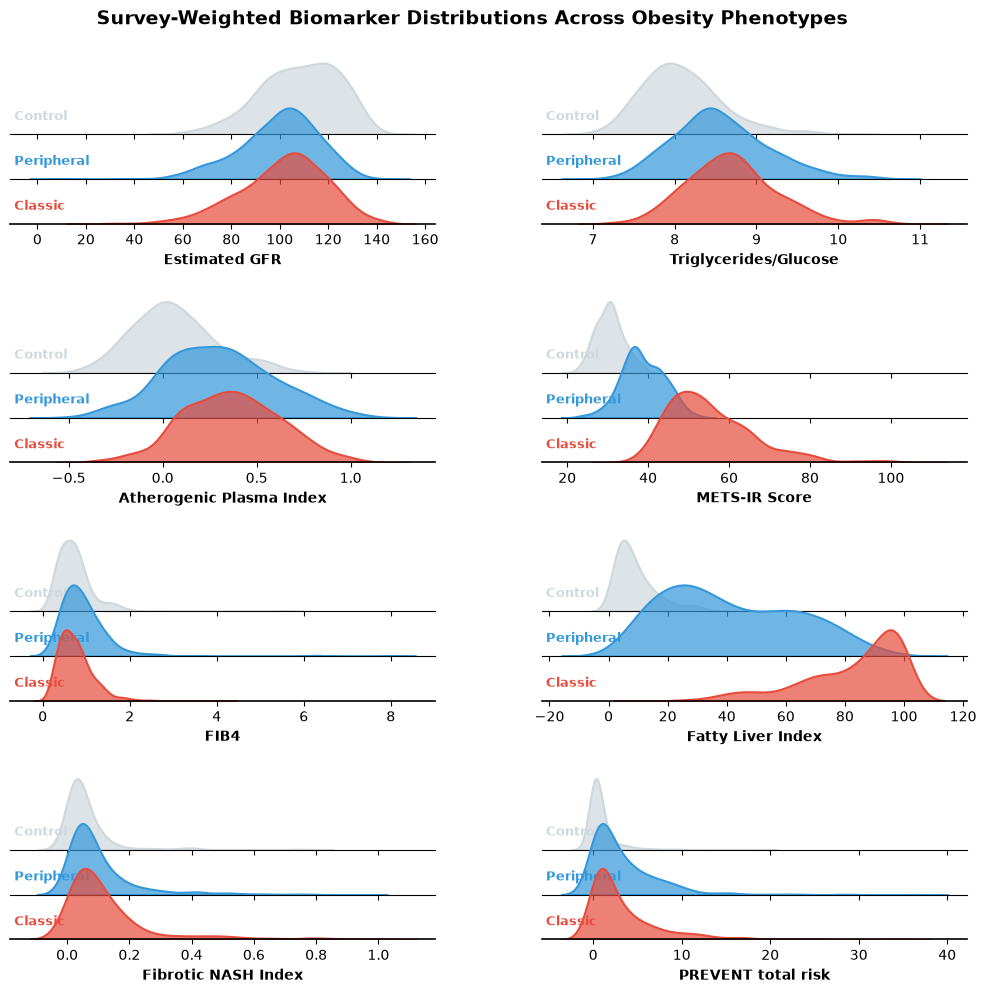

In [50]:
# Filter out unclassified rows to avoid polluting the control baseline
analysis_data = analysis.df[analysis.mask & (analysis.df["phenotype"] != "unclassified")]

# Define advanced predictive metabolic, hepatic, and fibrotic indices
indices = [
    "ckd_epi", "tyg", "api", "mets_ir", "fib4", "fli", "fni", "prevent_total"
]

viz = Visualizer(analysis_data)

label_mapping = {
    "ckd_epi": "Estimated GFR",
    "tyg": "Triglycerides/Glucose",
    "api": "Atherogenic Plasma Index",
    "mets_ir": "METS-IR Score",
    "fib4": "FIB4",
    "fli": "Fatty Liver Index",
    "fni": "Fibrotic NASH Index",
    "prevent_total": "PREVENT total risk"
}

# Accepts a list of biomarkers directly:
fig = viz.weighted_ridgeline(
    biomarkers=indices,
    label_map=label_mapping,
    title="Survey-Weighted Biomarker Distributions Across Obesity Phenotypes"
)

In [51]:
# Instantiate the Generalized Estimating Equation Regression engine
engine = Regression(analysis_data)

index_differences = engine.test_indices_phenotype_differences(
    biomarkers=indices, 
    phenotype_col="phenotype",
    weight_col="WTSAF2YR",
    label_map=label_mapping
)

display(index_differences)

,index,Control (Mean ± SD),Peripheral (Mean ± SD),Classic (Mean ± SD),Wald F-Test (p-value)
0,Estimated GFR,108.14 (±15.76),99.57 (±16.33),101.41 (±18.15),< 0.001
1,Triglycerides/Glucose,8.09 (±0.48),8.57 (±0.58),8.70 (±0.57),< 0.001
2,Atherogenic Plasma Index,0.06 (±0.22),0.30 (±0.29),0.37 (±0.26),< 0.001
3,METS-IR Score,30.45 (±3.41),38.67 (±5.23),55.37 (±10.86),< 0.001
4,FIB4,0.73 (±0.42),0.96 (±0.69),0.76 (±0.42),< 0.001
5,Fatty Liver Index,9.29 (±7.39),41.25 (±22.31),82.72 (±16.98),< 0.001
6,Fibrotic NASH Index,0.06 (±0.09),0.10 (±0.12),0.13 (±0.16),< 0.001
7,PREVENT total risk,0.96 (±2.02),3.38 (±3.94),3.37 (±4.14),< 0.001


### Diagnostic Gap: Self-Reported History vs. Objective End-Organ Damage
---

Comparing self-reported clinical diagnoses against biomarker/elastography evidence reveals substantial screening shortfalls in general population surveillance.

- **The Hepatic Diagnostic Gap:** In the Classic phenotype, 25.13% of individuals meet objective laboratory/elastography criteria for Hepatic Damage, yet only 4.30% report a formal diagnosis of Fatty Liver Disease and 5.63% report any liver condition history. This reveals an uncaptured diagnostic gap of ~20.8% in central obesity.

- **Metabolic Alignment:** Objective metabolic damage closely mirrors formal diabetes self-reports in Peripheral ($7.90\%$ objective vs $7.10\%$ reported) and Classic ($9.82\%$ objective vs $12.39\%$ reported) phenotypes, validating glycated hemoglobin/fasting plasma glucose screening efficiency relative to liver function monitoring.

- **Renal Subclinical Burden:** Objective renal damage reaches 1.54% in the Classic phenotype compared to a 1.11% self-reported kidney disease history, suggesting early subclinical hyperfiltration and microalbuminuria changes before overt clinical awareness.

In [52]:
# Define the target chronic condition variables
chronic = [
    "BPQ020", "BPQ150", "DIQ010", "DIQ050", "DIQ070", "MCQ160L", "MCQ510A", "MCQ510B", "KIQ022", "KIQ025", 
    "hepatic_damage", "metabolic_damage", "renal_damage" 
]

# Create a working copy of the cohort
chronic_df = df.copy()

# Recode: 1 -> 1, 2 -> 0, and anything else -> NaN
chronic_df[chronic] = chronic_df[chronic].apply(lambda col: col.map({1: 1, 2: 0, 0: 0}))

# Pass directly to Processor without calling whole-dataset dropna
analysis_chronic = Processor(chronic_df)

# Define the label map
label_map_chronic = {
    "BPQ020": "Hypertension History",
    "BPQ150": "Taking BP Medication",
    "DIQ010": "Diabetes Diagnosis",
    "DIQ050": "Taking Insulin",
    "DIQ070": "Taking Oral Diabetes Meds",
    "KIQ022": "Kidney Disease History",
    "KIQ025": "Dialysis History",
    "MCQ160L": "Liver Condition History",
    "MCQ510A": "Fatty Liver Diagnosis",
    "MCQ510B": "Liver Fibrosis Diagnosis",
    "hepatic_damage": "Hepatic damage",
    "metabolic_damage": "Metabolic damage",
    "renal_damage": "Renal damage"
}

analysis_chronic.table(chronic, label_map_chronic)

Fasting Cohort Size: 1816
Total Outliers from cohort: 228
Final Analysis Cohort Size: 1588


Mean                                  \
Phenotype                        overall   control peripheral    classic   
Variable                                                                   
Hypertension History (%)       22.276842  8.016022  22.343576  32.497468   
Taking BP Medication (%)       15.015689  2.310463  15.237883  23.807206   
Diabetes Diagnosis (%)          7.515542  2.340863   7.095067  12.387202   
Taking Insulin (%)              2.360371  2.213165   1.362248   3.999576   
Taking Oral Diabetes Meds (%)   6.383913  0.104991   6.141611   10.93388   
Liver Condition History (%)     4.139459  0.879359   4.962407   5.626311   
Fatty Liver Diagnosis (%)        2.33403       0.0    1.93228   4.301333   
Liver Fibrosis Diagnosis (%)         0.0       0.0        0.0        0.0   
Kidney Disease History (%)      1.354527  1.548045   1.859598   1.106324   
Dialysis History (%)            0.057715       0.0   0.184283        0.0   
Hepatic damage (%)             13.958776  4.078782   9.553978  25.133155   
Metabolic damage (%)            6.420817  0.094747   7.900546   9.815913   
Renal damage (%)                0.991005       0.0    0.92583   1.538503   

                                  P25                                P75  \
Phenotype                     overall control peripheral classic overall   
Variable                                                                   
Hypertension History (%)            -       -          -       -       -   
Taking BP Medication (%)            -       -          -       -       -   
Diabetes Diagnosis (%)              -       -          -       -       -   
Taking Insulin (%)                  -       -          -       -       -   
Taking Oral Diabetes Meds (%)       -       -          -       -       -   
Liver Condition History (%)         -       -          -       -       -   
Fatty Liver Diagnosis (%)           -       -          -       -       -   
Liver Fibrosis Diagnosis (%)        -       -          -       -       -   
Kidney Disease History (%)          -       -          -       -       -   
Dialysis History (%)                -       -          -       -       -   
Hepatic damage (%)                  -       -          -       -       -   
Metabolic damage (%)                -       -          -       -       -   
Renal damage (%)                    -       -          -       -       -   

                                                                SE            \
Phenotype                     control peripheral classic   overall   control   
Variable                                                                       
Hypertension History (%)            -          -       -  1.058917   1.93219   
Taking BP Medication (%)            -          -       -   1.09421  0.922891   
Diabetes Diagnosis (%)              -          -       -  0.635823  1.549033   
Taking Insulin (%)                  -          -       -  0.453741  1.523477   
Taking Oral Diabetes Meds (%)       -          -       -  0.639674  0.107381   
Liver Condition History (%)         -          -       -  0.534061   0.60084   
Fatty Liver Diagnosis (%)           -          -       -   0.40641       0.0   
Liver Fibrosis Diagnosis (%)        -          -       -       0.0       0.0   
Kidney Disease History (%)          -          -       -  0.288194  0.770197   
Dialysis History (%)                -          -       -  0.040525       0.0   
Hepatic damage (%)                  -          -       -  1.116619  1.334468   
Metabolic damage (%)                -          -       -  0.721778  0.095306   
Renal damage (%)                    -          -       -   0.24924       0.0   

                                                   N_Valid                     \
Phenotype                     peripheral   classic overall control peripheral   
Variable                                                                        
Hypertension History (%)        2.173232   2.39419    1816     272        585 

### Primary Phenotypic Stratification (Model M1)
---

In survey-weighted GEE Poisson regression adjusted for age, sex, race/ethnicity, and chronic disease history, baseline body composition phenotypes exhibited a strong association with the target outcome. Relative to non-obese controls, individuals classified under the Peripheral Obesity phenotype demonstrated a nearly two-fold increase in risk ($RR = 1.95, 95\%\text{ CI: } [1.04, 3.66], p = 0.038$). The risk was markedly pronounced among individuals with the Classic Obesity phenotype, who presented a more than five-fold increase in risk ($RR = 5.19, 95\%\text{ CI: } [2.94, 9.17], p < 0.001$). Overall model fit for the primary phenotypic architecture yielded a Quasi-Likelihood under the Independence Model Criterion ($\text{QIC}$) of $847.05$.

In [53]:
# Define variables avoiding circular logic (e.g., assessing hepatic damage using strictly metabolic markers)
cofounders = ["RIDAGEYR", "RIAGENDR", "RIDRETH3", "has_hx_chronic_disease"]
hepatic_spillover = ["mets_ir", "tyg", "api"]

# Execute the Model 1 Baseline (Predicting Hepatic Damage using only Structural Phenotypes)
m1_hepatic = engine.model_1_phenotype("hepatic_damage", hepatic_spillover, cofounders)

 MODEL: M1_Phenotype
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -3.2821      0.337     -9.745      0.000      -3.942      -2.622
has_hx_chronic_disease[T.True]     0.2394      0.174      1.379      0.168      -0.101       0.580
phenotype_peripheral               0.6665      0.322      2.071      0.038       0.036       1.297
phenotype_classic                  1.6470      0.290      5.676      0.000       1.078       2.216
RIDAGEYR                           0.0104      0.007      1.527      0.127      -0.003       0.024
RIAGENDR                          -0.2534      0.126     -2.019      0.044      -0.500      -0.007
RIDRETH3                           0.0205      0.049      0.417      0.677      -0.076       0.117
----------------------------------------------------------------------------------------

### Isolated Metabolic Surrogate Performance (Model M2)
---

Evaluating surrogate markers of insulin resistance and lipid atherogenicity independently in single-surrogate models revealed varying predictive capacities:

- **METS-IR Cutoff:** Exhibited the strongest univariable association among all surrogates ($RR = 3.79, 95\%\text{ CI: } [3.06, 4.69], p < 0.001$) and markedly improved model parsimony ($\text{QIC} = 822.24$).

- **API Cutoff:** Demonstrated a significant positive risk association ($RR = 1.53, 95\%\text{ CI: } [1.16, 2.00], p = 0.002, \text{QIC} = 903.88$).

- **TyG Cutoff:** Similarly predicted elevated risk ($RR = 1.46, 95\%\text{ CI: } [1.13, 1.90], p = 0.004, \text{QIC} = 903.01$).

In [54]:
# Apply established clinical diagnostic thresholds to continuous biochemical indices
# This transforms continuous risk scores into actionable binary indicators for regression modeling.
analysis.index_cutoff(variable="tyg", cutoff=">= 8.65", label="tyg_cutoff")
analysis.index_cutoff(variable="api", cutoff="> 0.5", label="api_cutoff")
analysis.index_cutoff(variable="mets_ir", cutoff="> 50.39", label="mets_ir_cutoff")

# Apply dual-threshold logic for hepatic/fibrotic indices.
# Patients falling between rule-out and rule-in values are classified as 'indeterminate'.
analysis.index_indeterminates("fib4", rule_out="< 1.45", rule_in="> 3.25", label="fib4_indeterminate")
analysis.index_indeterminates("fli",  rule_out="< 30",   rule_in=">= 60",  label="fli_indeterminate")
analysis.index_indeterminates("fni",  rule_out="<= 0.10", rule_in=">= 0.33", label="fni_indeterminate")

# Update the main operational dataframe with the newly generated categorical columns
df = analysis.df


In [55]:
# Isolate the analytical cohort explicitly, removing 'unclassified' outliers 
regression_data = analysis.df[analysis.mask & (analysis.df["phenotype"] != "unclassified")]

# Initialize a dedicated Regression engine for hepatic end-organ damage evaluation
engine_hepatic = Regression(regression_data)

# Define the binary categorical variants of the cross-spillover indices
hepatic_spillover = ["mets_ir_cutoff", "tyg_cutoff", "api_cutoff"]
m2_models = {}

"""
Iterate through each defined clinical threshold to run Model 2.
This evaluates the independent predictive capacity of each biochemical index on hepatic damage, adjusting 
for standard demographic confounders.
"""
for idx in hepatic_spillover:
    m2_key = f"m2_hepatic_spill_{idx}"
    m2_models[m2_key] = engine_hepatic.model_2_cross_spill("hepatic_damage", idx, hepatic_spillover, cofounders)

 MODEL: M2_CrossSpill (mets_ir_cutoff)
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -2.7948      0.304     -9.187      0.000      -3.391      -2.199
has_hx_chronic_disease[T.True]     0.1643      0.173      0.949      0.343      -0.175       0.504
mets_ir_cutoff                     1.3318      0.109     12.247      0.000       1.119       1.545
RIDAGEYR                           0.0142      0.006      2.196      0.028       0.002       0.027
RIAGENDR                          -0.2682      0.126     -2.124      0.034      -0.516      -0.021
RIDRETH3                           0.0196      0.049      0.398      0.691      -0.077       0.116
--------------------------------------------------------------------------------------------------
 Fit Metrics:  QIC = 822.236  |  N = 1588  |  Clusters = 30

 MODEL: M

### Integrated Models & Signal Attenuation (Model M3)
---

- **METS-IR Integration:** The addition of METS-IR produced the best overall model fit across all specifications ($\text{QIC} = 815.71$). Even after controlling for phenotypic categories, METS-IR maintained a strong, independent risk association ($RR = 2.87, 95\%\text{ CI: } [2.01, 4.11], p < 0.001$). Adjustment for METS-IR attenuated the Classic Obesity phenotype risk from $RR = 5.19$ to $RR = 2.44$ ($p = 0.011$). This persistence highlights METS-IR's unique mathematical incorporation of continuous $\text{BMI}$, which likely captures continuous adiposity chronicity and cumulative tissue exposure alongside fasting glycemic/lipid dysregulation.

- **TyG Integration:** When combined with obesity phenotypes, TyG lost statistical significance ($RR = 1.17, p = 0.232$), while Peripheral ($RR = 1.88, p = 0.049$) and Classic obesity ($RR = 4.92, p < 0.001$) retained their risk estimates ($\text{QIC} = 844.43$).

- **API Integration:** Similarly, API was attenuated to non-significance upon adjusting for obesity phenotypes ($RR = 1.26, p = 0.088$), while the later remained strong predictors ($\text{QIC} = 843.06$). These attenuations suggest that fasting lipid/glycemic ratios alone without anthropometric parameters do not add incremental predictive value over obesity phenotypes.

In [56]:
m3_models = {}
"""
Iterate through each defined clinical threshold to run Model 3.
This integrates both the structural phenotypes and the specific biochemical index, determining 
if the combination yields a superior predictive model (via QIC score).
"""
for idx in hepatic_spillover:
    m3_key = f"m3_integrated_{idx}"
    m3_models[m3_key] = engine_hepatic.model_3_integrated("hepatic_damage", idx, hepatic_spillover, cofounders)

 MODEL: M3_Integrated (mets_ir_cutoff)
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -3.2969      0.341     -9.659      0.000      -3.966      -2.628
has_hx_chronic_disease[T.True]     0.1502      0.169      0.887      0.375      -0.182       0.482
phenotype_peripheral               0.6450      0.323      1.996      0.046       0.012       1.278
phenotype_classic                  0.8939      0.354      2.528      0.011       0.201       1.587
mets_ir_cutoff                     1.0549      0.183      5.758      0.000       0.696       1.414
RIDAGEYR                           0.0116      0.007      1.730      0.084      -0.002       0.025
RIAGENDR                          -0.2692      0.125     -2.152      0.031      -0.514      -0.024
RIDRETH3                           0.0238      0.048      0.497      0

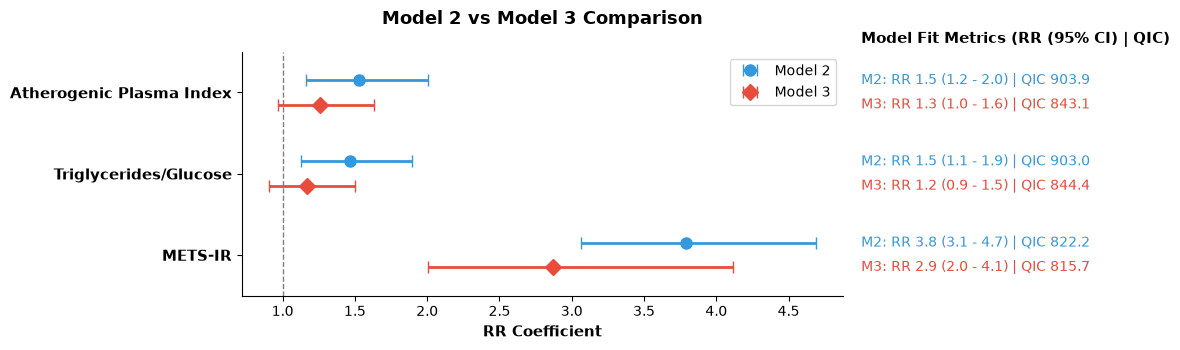

In [57]:
# Instantiate the Visualizer class with the established cutoff per index
viz = Visualizer(regression_data)

forest_label_mapping = {
    "mets_ir_cutoff": "METS-IR",
    "tyg_cutoff": "Triglycerides/Glucose",
    "api_cutoff": "Atherogenic Plasma Index"
}

forest_plot = viz.forest_comparison(
    index_list=hepatic_spillover, 
    m2_dict=m2_models, 
    m3_dict=m3_models, 
    m2_prefix="m2_hepatic_spill_", 
    m3_prefix="m3_integrated_", 
    label_map=forest_label_mapping,
    title="Model 2 vs Model 3 Comparison"
)

### Phenotype-Stratified METS-IR Effect Modification
---

To evaluate whether the impact of metabolic insulin resistance (METS-IR) on hepatic damage varies across distinct structural obesity phenotypes, subgroup-stratified survey-weighted Generalized Estimating Equations (GEE) with a Poisson family and log link were executed.

Stratification was preferred over pooled multiplicative interaction modeling to prevent variance inflation stemming from exposure sparsity within the non-obese control reference stratum ($N = 272$), where elevated METS-IR prevalence was near zero. Stratified models were fitted independently for the Peripheral Obesity ($N = 585$) and Classic Obesity ($N = 731$) cohorts, adjusting for age, sex, race/ethnicity, and baseline chronic disease history.

Stratified GEE Poisson regressions revealed that elevated METS-IR independently increases the risk of hepatic damage across both obesity phenotypes, though with distinct risk magnitudes:

- **Peripheral Obesity Phenotype ($N = 585$):** Among individuals with peripheral/gynoid adiposity distribution, an elevated METS-IR score was associated with a 3.6-fold increase in the relative risk of hepatic damage ($RR = 3.60, 95\%\text{ CI: } [1.51, 8.57], p = 0.004$). Within this stratum, baseline chronic disease history also remained an independent risk factor ($RR = 1.96, 95\%\text{ CI: } [1.17, 3.27], p = 0.010$).

- **Classic Obesity Phenotype ($N = 731$):** Among individuals presenting with classic central/visceral adiposity, elevated METS-IR similarly conferred a significant increase in risk ($RR = 2.76, 95\%\text{ CI: } [1.98, 3.85], p < 0.001$).

*Note: Models fit via survey-weighted GEE Poisson regression adjusted for age, sex, race/ethnicity, and chronic disease history. Control group omitted due to insufficient exposure variation ($0$ positivity in high METS-IR cell).*

In [58]:
"""
Execute stratified regressions to quantify the distinct Relative Risk (RR) of METS-IR 
strictly within the bounds of each structural phenotype.
"""
models_isolated = {}

for pheno in ["control", "peripheral", "classic"]:
    # Isolate the specific clinical stratum
    stratum_df = regression_data[regression_data["phenotype"] == pheno]

    if stratum_df["mets_ir_cutoff"].nunique() < 2:
        print(f"Skipping {pheno}: Insufficient cutoff variation.\n")
        continue

    pheno_key = f"m_phenotype_isolated_{pheno}"
    models_isolated[pheno_key] = smf.gee(
        formula="hepatic_damage ~ mets_ir_cutoff + RIDAGEYR + RIAGENDR + RIDRETH3 + has_hx_chronic_disease",
        groups="groups",
        data=stratum_df,
        family=sm.families.Poisson(link=sm.families.links.Log()),
        cov_struct=sm.cov_struct.Exchangeable(),
        weights=stratum_df["WTSAF2YR"]
    ).fit()

    qic, _ = models_isolated[pheno_key].qic(scale=1.0)

    # Format and display the output table for the specific phenotype
    print(f"=" * 83)
    print(f"METS-IR EFFECT IN {pheno.upper()} PHENOTYPE")
    print(f"-" * 83)
    print(models_isolated[pheno_key].summary())
    print(f"\n")

Skipping control: Insufficient cutoff variation.

METS-IR EFFECT IN PERIPHERAL PHENOTYPE
-----------------------------------------------------------------------------------
                               GEE Regression Results                              
Dep. Variable:              hepatic_damage   No. Observations:                  585
Model:                                 GEE   No. clusters:                       30
Method:                        Generalized   Min. cluster size:                   6
                      Estimating Equations   Max. cluster size:                  35
Family:                            Poisson   Mean cluster size:                19.5
Dependence structure:         Exchangeable   Num. iterations:                    12
Date:                     Sat, 01 Aug 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         16:22:45
                                     coef    std err          z      P>

### Population Flow & Visual Trajectory Analysis (Sankey Mapping)
---

To visualize how standard anthropometric metrics transition through physical body composition phenotypes and metabolic insulin resistance to ultimate end-organ outcomes, survey-weighted Sankey trajectory diagrams were mapped across three core analytical frameworks.

#### **Standard BMI $\rightarrow$ Body Phenotype $\rightarrow$ Multi-Organ End Targets**

The primary flow illustrates the structural re-classification of standard BMI categories into distinct clinical risk trajectories:

- **Phenotypic Divergence of Obesity:** Individuals classified as Overweight ($\text{BMI } 25.0\text{--}29.9\text{ kg/m}^2$) bifurcate into the Peripheral Obesity Phenotype. A small subset of normal BMI transitioned into the Classic Phenotype.

- **Classic Phenotype Consolidation:** Obese individuals ($\text{BMI } \ge 30\text{ kg/m}^2$) flow unanimously into the Classic Phenotype, representing central/visceral adiposity distribution.

- **Organ Target Stratification:**

    - The Control cohort transitions almost exclusively to the No Organ Damage terminus.
    - The Peripheral Phenotype predominantly remains free of organ damage, though a distinct sub-stream channels into isolated Hepatic Damage (+) and minor single-domain outcomes.
    - The Classic Phenotype serves as the primary reservoir for Multi-Organ Dysfunction ($\ge 2$ damaged domains) as well as substantial independent flows into Hepatic Damage (+) and Isolated Metabolic Damage.

In [59]:
# Instantiate the Visualizer class and create a new composite column for end-organ damage
sankey_df = viz.end_organ_composite()

# Create BMI bins for categorization
sankey_df["bmi_category"] = pd.cut(
    sankey_df["BMXBMI"],
    bins=[18.5, 24.99, 29.99, 100],
    labels=["normal", "overweight", "obese"],
)

# Tier order mapping
explicit_order_organ_damage = {
    "bmi_category": ["normal", "overweight", "obese"],
    "phenotype": ["control", "peripheral", "classic"],
    "end_organ_outcome": [
        "none",
        "metabolic_only",
        "renal_only",
        "hepatic_only",
        "multi_organ",
    ],
}

# Tier label mpapping
nested_labels_organ_damage = {
    "bmi_category": {
        "normal": "Normal Weight (18.5-25)",
        "overweight": "Overweight (25-29.9)",
        "obese": "Obese (≥30)"
    },
    "phenotype": {
        "control": "Control (Healthy)",
        "peripheral": "Peripheral Phenotype",
        "classic": "Classic Phenotype",
    },
    "end_organ_outcome": {
        "none": "No Organ Damage",
        "metabolic_only": "Isolated Metabolic",
        "renal_only": "Renal Damage (+)",
        "hepatic_only": "Hepatic Damage (+)",
        "multi_organ": "Multi-Organ Dysfunction (2+)",
    },
}

# Tier color mapping
nested_colors_organ_damage = {
    "bmi_category": {
        "normal": "#CFD8DC",      
        "overweight": "#3b7ca7",  
        "obese": "#d25d51",       
    },
    "phenotype": {
        "control": "#CFD8DC",  
        "peripheral": "#3b7ca7",  
        "classic": "#d25d51",  
    },
    "end_organ_outcome": {
        "none": "#CFD8DC",  
        "metabolic_only": "#d25d51",  
        "renal_only": "#d25d51",  
        "hepatic_only": "#d25d51",  
        "multi_organ": "#e6b800",  
    }
}

fig_organ_damage = viz.patient_sankey(
    df=sankey_df,
    tiers=["bmi_category", "phenotype", "end_organ_outcome"],
    tier_names=[
        "1. BMI Category",
        "2. Clinical Phenotype",
        "3. End-Organ Damage Target",
    ],
    tier_order=explicit_order_organ_damage,
    label_map=nested_labels_organ_damage,
    color_map=nested_colors_organ_damage,
    weight_col="WTSAF2YR",
    title="Survey-Weighted Trajectory: BMI → Phenotype → Multi-Organ End Targets",
)

fig_organ_damage.show()

#### **BMI $\rightarrow$ Phenotype $\rightarrow$ METS-IR Risk $\rightarrow$ Hepatic Damage**

Evaluating the specific intermediate funneling effect of insulin resistance ($\text{METS-IR} > 50.39$) on hepatic end-target damage reveals:

- **Metabolic Funneling:** The transition from physical phenotype to elevated metabolic risk is heavily dominated by the Classic Phenotype. While a small fraction of the Peripheral Phenotype crosses into the High METS-IR stratum ($> 50.39$), the vast majority of Peripheral individuals remain within the Normal METS-IR band ($\le 50.39$).

- **Hepatic Outcome Concentration:** Individuals maintaining Normal METS-IR flow overwhelmingly into No Hepatic Damage. Conversely, the High METS-IR stream captures the majority of downstream Hepatic Damage (+) cases. This highlights that metabolic insulin resistance is a key proximal driver translating central adiposity into overt liver injury.

In [60]:
# Tier order mapping
explicit_order_mets_ir = {
    "bmi_category": ["normal", "overweight", "obese"],
    "phenotype": ["control", "peripheral", "classic"],
    "mets_ir_cutoff": [0.0, 1.0, 0, 1],
    "hepatic_damage": [0.0, 1.0, 0, 1],
}

# Tier label mapping
nested_labels_mets_ir = {
    "bmi_category": {
        "normal": "Normal Weight (18.5-25)",
        "overweight": "Overweight (25–29.9)",
        "obese": "Obese (≥30)"
    },
    "phenotype": {
        "control": "Control (Healthy)",
        "classic": "Classic Phenotype",
        "peripheral": "Peripheral Phenotype"
    },
    "mets_ir_cutoff": {
        0.0: "Normal METS-IR (≤50.39)",
        1.0: "High METS-IR (>50.39)",
        0: "Normal METS-IR (≤50.39)",
        1: "High METS-IR (>50.39)"
    },
    "hepatic_damage": {
        0.0: "No Hepatic Damage",
        1.0: "Hepatic Damage (+)",
        0: "No Hepatic Damage",
        1: "Hepatic Damage (+)"
    },
}

# Tier color mapping
nested_colors_mets_ir = {
    "bmi_category": {
        "normal": "#CFD8DC",      
        "overweight": "#3b7ca7",  
        "obese": "#d25d51",       
    },
    "phenotype": {
        "control": "#CFD8DC",     
        "peripheral": "#3b7ca7",  
        "classic": "#d25d51",     
    },
    
    "mets_ir_cutoff": {
        0.0: "#CFD8DC", 1.0: "#d25d51",
        0: "#CFD8DC",   1: "#d25d51"
    },
    "hepatic_damage": {
        0.0: "#CFD8DC", 1.0: "#d25d51",
        0: "#CFD8DC",   1: "#d25d51"
    }
}

fig_mets_ir = viz.patient_sankey(
    df=sankey_df,
    tiers=["bmi_category", "phenotype", "mets_ir_cutoff", "hepatic_damage"],
    tier_names=[
        "1. BMI Category",
        "2. Visual Phenotype",
        "3. Metabolic Risk (METS-IR)",
        "4. End-Organ Outcome",
    ],
    tier_order=explicit_order_mets_ir,
    label_map=nested_labels_mets_ir,
    color_map=nested_colors_mets_ir,
    weight_col="WTSAF2YR",
    title="Survey-Weighted Trajectory: BMI → Phenotype → METS-IR Risk → Hepatic Damage",
)

fig_mets_ir.show()

#### **Phenotype $\rightarrow$ Domain Clustering $\rightarrow$ End-Organ Targets**

Evaluating risk accumulation across individual pathology domains (Renal, Metabolic, or Hepatic) demonstrates how physical phenotypes drive single- versus multi-domain organ vulnerability:

- **Domain Definitions:**

    - **Single-Domain Risk:** Isolated involvement of exactly one target organ domain (Renal, Metabolic, or Hepatic).
    - **Multi-Domain High Risk:** Concurrent pathology fulfilling end-organ damage criteria across at least two ($\ge 2$) distinct domains.
- **Flow Trajectories:**
    - **Peripheral Phenotype:** Primarily feeds into the Normal or Single-Domain Risk intermediate tiers, terminating mostly in No Organ Damage or isolated single-organ endpoints (dominated by Hepatic Damage).`
    - **Classic Phenotype:** Generates the vast majority of the Multi-Domain High Risk intermediate pool.
    - **Downstream Convergence:** The Multi-Domain High Risk intermediate stream flows almost entirely into single-domain endpoints (Hepatic and Metabolic Damage), demonstrating that visceral adiposity triggers mostly hepatic end-organ damage.

In [61]:
"""
Instantiate the Visualizer class with the composite end-organ damage column and create a new 
composite column for domain risks based on specific indices thresholds
"""
viz = Visualizer(sankey_df)
index_df = viz.prepare_two_index_sankey(metabolic_index="mets_ir_cutoff", hepatic_index="fli_rule_in")

# Tier order mapping
explicit_order_framework = {
    "phenotype": ["control", "peripheral", "classic"],
    "index_risk_tier": ["Low Index Risk", "Single-Domain Risk", "Multi-Domain High Risk"],
    "end_organ_outcome": [
        "none",
        "metabolic_only",
        "renal_only",
        "hepatic_only",
        "multi_organ",
    ],
}

# Tier label mapping
nested_labels_framework = {
    "phenotype": {
        "control": "Control (Healthy)",
        "peripheral": "Peripheral Phenotype",
        "classic": "Classic Phenotype",
    },
    "index_risk_tier": {
        "Low Index Risk": "Normal",
        "Single-Domain Risk": "Single-Domain Risk",
        "Multi-Domain High Risk": "Multi-Domain High Risk"
    },
    "end_organ_outcome": {
        "none": "No Organ Damage",
        "metabolic_only": "Metabolic Damage (+)",
        "renal_only": "Renal Damage (+)",
        "hepatic_only": "Hepatic Damage (+)",
        "multi_organ": "Multi-Organ Dysfunction (2+)",
    },
}

# Tier color mapping
nested_colors_framework = {
    "phenotype": {
        "control": "#CFD8DC",  
        "peripheral": "#3b7ca7",  
        "classic": "#d25d51",  
    },
    "index_risk_tier": {
        "Low Index Risk": "#CFD8DC",  
        "Single-Domain Risk": "#3b7ca7",  
        "Multi-Domain High Risk": "#d25d51",  
    },
    "end_organ_outcome": {
        "none": "#CFD8DC",  
        "metabolic_only": "#d25d51",  
        "renal_only": "#d25d51",  
        "hepatic_only": "#d25d51",  
        "multi_organ": "#e6b800",  
    },
}

fig_framework = viz.patient_sankey(
    df=index_df,
    tiers=["phenotype", "index_risk_tier", "end_organ_outcome"],
    tier_names=[
        "1. Clinical Phenotype",
        "2. Index risk",
        "3. End-Organ Damage Target",
    ],
    tier_order=explicit_order_framework,
    label_map=nested_labels_framework,
    color_map=nested_colors_framework,
    weight_col="WTSAF2YR",
    title="Survey-Weighted Trajectory: Phenotype → Metabolic Risk → Multi-Organ End Targets",
)

fig_framework.show()

### Visualizing Multi-Organ Risk Trajectories Across Adiposity Phenotypes
---

Survey-weighted Sankey trajectory mapping demonstrated clear divergence in end-organ vulnerability based on our proposed obesity phenotypes and metabolic insulin resistance ($\text{METS-IR}$). Standard body mass index categories binned individuals into physical phenotypes, with overweight ($\text{BMI } 25.0\text{--}29.9\text{ kg/m}^2$) splitting into peripheral adiposity, while obesity ($\text{BMI } \ge 30\text{ kg/m}^2$) consolidated into the Classic phenotype.

Intermediate risk mapping revealed that METS-IR ($> 50.39$) serves as an important metabolic gateway to end-organ harm: the Classic phenotype contributed the overwhelmingly dominant flow into high METS-IR, which subsequently accounted for the majority of observed Hepatic Damage (+) cases.

Furthermore, when assessing domain clustering across renal, metabolic, and hepatic spheres, the Peripheral phenotype largely restricted risk to single-domain involvement or no damage. In contrast, the Classic phenotype served as the primary origin for Multi-Domain High Risk ($\ge 2$ affected domains), which downstream drove systemic Multi-Organ Dysfunction ($2+$ domains). These visual trajectories reinforce that obesity phenotypes coupled with continuous metabolic insulin resistance escalates risk from isolated tissue strain to multi-system organ damage.